# Question 1

Best feature: Glucose, score: 213.1618
Worst feature: BloodPressure, score: 3.2570


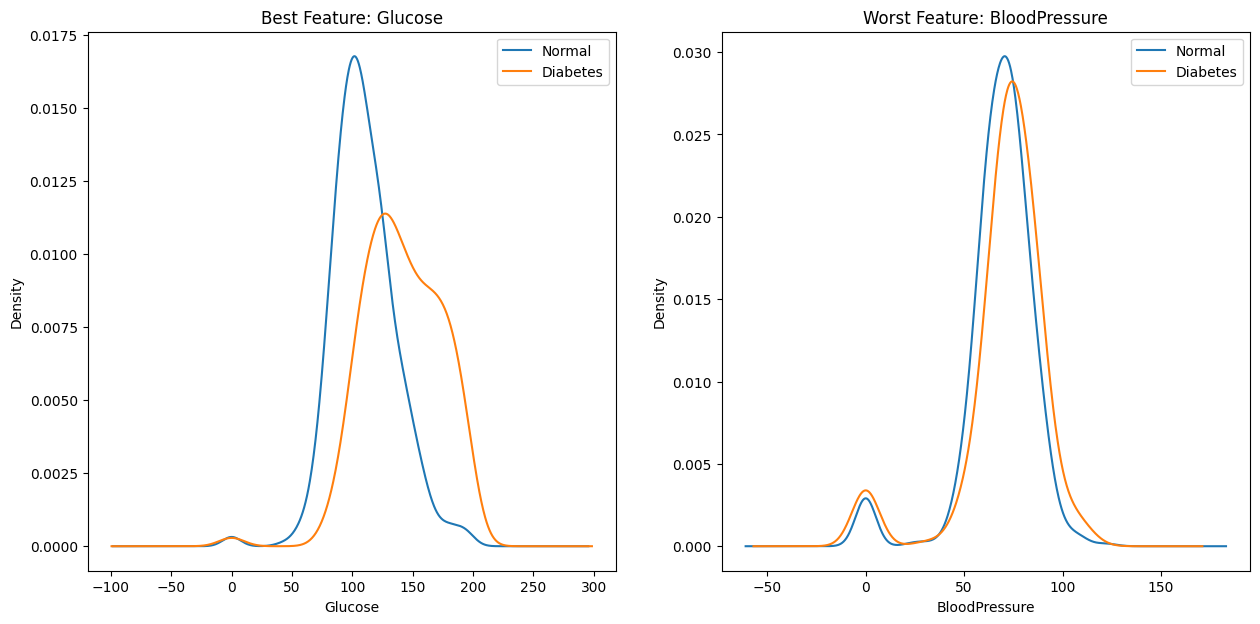

In [8]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import f_classif
from scipy.io import arff
import matplotlib.pyplot as plt

data = arff.loadarff("diabetes.arff")
df = pd.DataFrame(data[0])
df['Outcome'] = df['Outcome'].astype(int)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Find the best and worst features
f_importance = f_classif(X, y)
best_index = np.argmax(f_importance[0])
worst_index = np.argmin(f_importance[0])
best_feature = X.columns[best_index]
worst_feature = X.columns[worst_index]
print(f'Best feature: {best_feature}, score: {f_importance[0][best_index]:.4f}')
print(f'Worst feature: {worst_feature}, score: {f_importance[0][worst_index]:.4f}')

# Plotting
plt.figure(figsize=(15, 7))

plt.subplot(1, 2, 1)
df[df['Outcome'] == 0][best_feature].plot(kind='density', label='Normal', title=f'Best Feature: {best_feature}')
df[df['Outcome'] == 1][best_feature].plot(kind='density', label='Diabetes')
plt.xlabel(best_feature)
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 2, 2)
df[df['Outcome'] == 0][worst_feature].plot(kind='density', label='Normal', title=f'Worst Feature: {worst_feature}')
df[df['Outcome'] == 1][worst_feature].plot(kind='density', label='Diabetes')
plt.xlabel(worst_feature)
plt.ylabel('Density')
plt.legend()

plt.show()

# Question 2

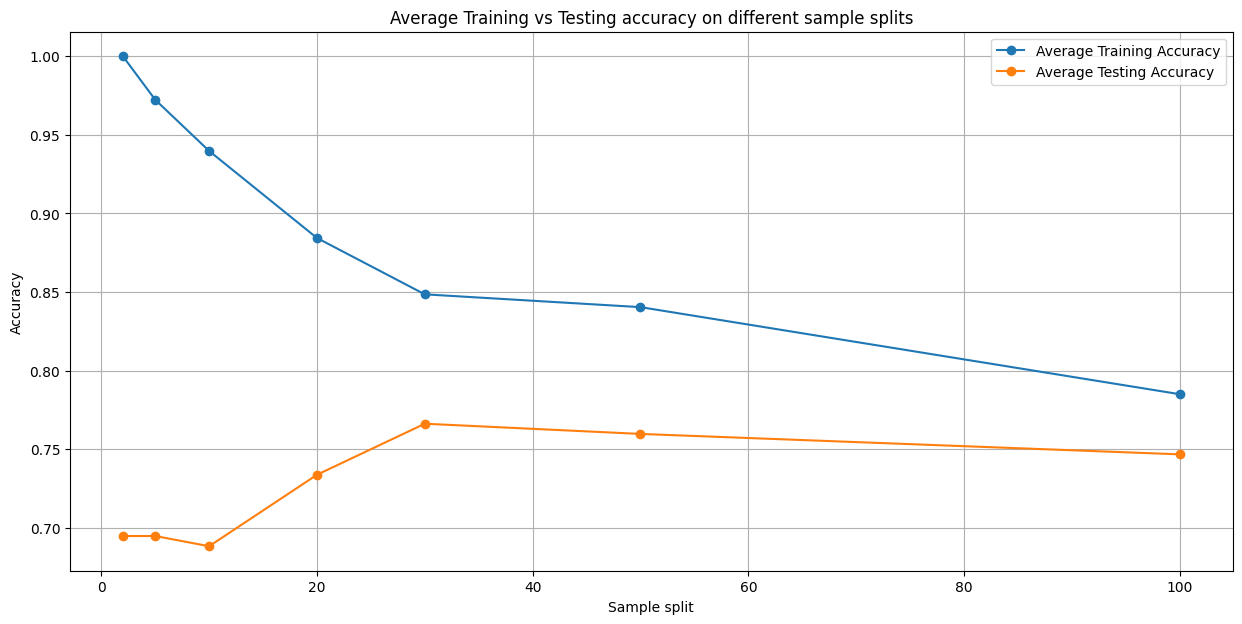

In [9]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = arff.loadarff("diabetes.arff")
df = pd.DataFrame(data[0])
df['Outcome'] = df['Outcome'].astype(int)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

min_samples_splits = [2, 5, 10, 20, 30, 50, 100]
avg_train_accuracies = []
avg_test_accuracies = []
runs = 10

for min_samples_split in min_samples_splits:
    train_acc = []
    test_acc = []
    for i in range(runs):
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=1)
        predictor = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=1)
        predictor.fit(X_train, y_train)
        y_train_pred = predictor.predict(X_train)
        y_test_pred = predictor.predict(X_test)
        train_acc.append(accuracy_score(y_train, y_train_pred))
        test_acc.append(accuracy_score(y_test, y_test_pred))
    avg_train_accuracies.append(np.mean(train_acc))
    avg_test_accuracies.append(np.mean(test_acc))

# Plotting
plt.figure(figsize=(15, 7))
plt.plot(min_samples_splits, avg_train_accuracies, label='Average Training Accuracy', marker='o')
plt.plot(min_samples_splits, avg_test_accuracies, label='Average Testing Accuracy', marker='o')
plt.xlabel('Sample split')
plt.ylabel('Accuracy')
plt.title('Average Training vs Testing accuracy on different sample splits')
plt.legend()
plt.grid(True)
plt.show()

# Question 3

Através da análise do gráfico, fica evidenciado o impacto que fenómenos como ‘overfitting’ ou ‘underfitting’ podem ter na ‘accuracy’ de um determinado modelo.
Até ao ‘sample split’ mínimo de cerca de 30, é visível um fenómeno de ‘overfitting’ em que o modelo está demasiado adequado às variáveis de teste, por ter uma árvore muito profunda. 
Por outro lado, principalmente a partir do ‘sample split’ mínimo de 50, começa-se a notar um decréscimo na performance da árvore de decisão, devido ao ‘underfitting’, que ocorre pela falta de profundidade da árvore.
Assim sendo, um ‘sample split’ mínimo com valores entre os 30 e os 50 parece o mais adequado para obter uma árvore com boa capacidade de generalização para análise de novas instâncias que não pertenciam ao treino.

# Question 4 i.

Probabilities: [[0.39130435 0.60869565]
 [0.60115607 0.39884393]
 [0.48571429 0.51428571]
 ...
 [0.95121951 0.04878049]
 [0.60115607 0.39884393]
 [0.92509363 0.07490637]]


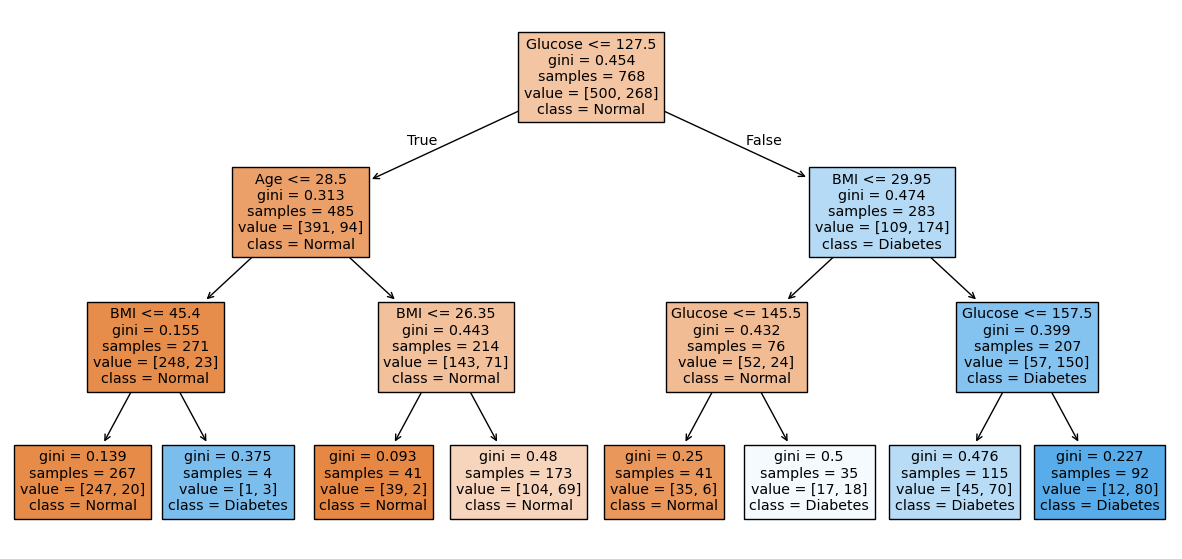

In [10]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

data = arff.loadarff("diabetes.arff")
df = pd.DataFrame(data[0])
df['Outcome'] = df['Outcome'].astype(int)

X = df.drop('Outcome', axis=1)
y = df['Outcome']

predictor = DecisionTreeClassifier(random_state=1, max_depth=3)
predictor.fit(X, y)
probs = predictor.predict_proba(X)
print(f'Probabilities: {probs}')

# Plotting
plt.figure(figsize=(15, 7))
tree.plot_tree(predictor, feature_names=X.columns, class_names=['Normal', 'Diabetes'], filled=True)
plt.show()

# Question 4 ii.

Através da análise do gráfico, podemos observar que diabetes é caracterizada por associações condicionais, tais como níveis elevados de glucose, IMC elevado e idade. Um IMC ≥ 29,95 tem uma probabilidade posterior de conduzir a um diagnóstico de diabetes com 174/283 = 61.5%, os níveis de glucose ≤ 127,5 com 500/768 = 65.1% e a idade ≤ 28,5 com 391/485.